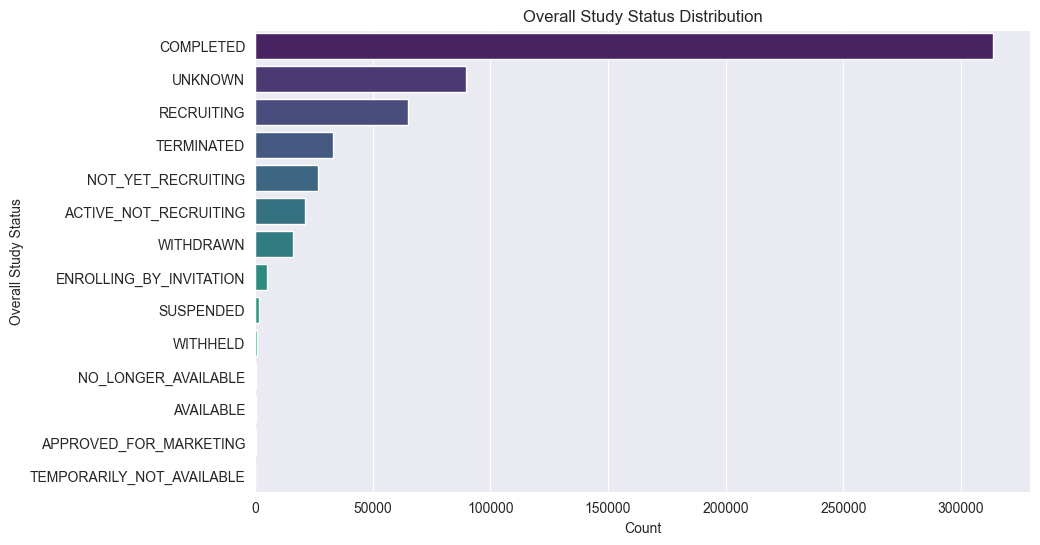

In [3]:
import sys
import os

sys.path.append(os.path.abspath('../src'))

from test_connection import get_connection
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

engine = get_connection()

query = "SELECT overall_status, COUNT(*) as count FROM aact.ctgov.studies GROUP BY overall_status ORDER BY count DESC;"
df_status = pd.read_sql(query, engine)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_status, x='count', y='overall_status', hue='overall_status', palette='viridis', legend=False)
plt.title('Overall Study Status Distribution')
plt.xlabel('Count')
plt.ylabel('Overall Study Status')
plt.show()

In [14]:
# Get the necessary data
# Use LEFT JOIN to not lose studies

query = """
SELECT
    s.nct_id,
    s.study_type,
    s.overall_status,
    s.phase,
    s.enrollment,
    s.has_dmc,
    s.is_fda_regulated_drug,
    s.start_date,
    sp.agency_class AS sponsor_type,
    cv.number_of_facilities,
    cv.actual_duration
FROM ctgov.studies s
LEFT JOIN ctgov.sponsors sp ON s.nct_id = sp.nct_id AND sp.lead_or_collaborator = 'lead'
LEFT JOIN ctgov.calculated_values cv ON s.nct_id = cv.nct_id
WHERE s.study_type = 'INTERVENTIONAL'
  AND s.overall_status IN ('COMPLETED', 'TERMINATED', 'WITHDRAWN', 'SUSPENDED')
"""

df = pd.read_sql(query, engine)

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 288827 entries, 0 to 288826
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   nct_id                 288827 non-null  str    
 1   study_type             288827 non-null  str    
 2   overall_status         288827 non-null  str    
 3   phase                  288720 non-null  str    
 4   enrollment             285578 non-null  float64
 5   has_dmc                240563 non-null  object 
 6   is_fda_regulated_drug  137263 non-null  object 
 7   start_date             286281 non-null  object 
 8   sponsor_type           288827 non-null  str    
 9   number_of_facilities   288827 non-null  int64  
 10  actual_duration        266846 non-null  float64
dtypes: float64(2), int64(1), object(3), str(5)
memory usage: 24.2+ MB
